In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline
# Tải dữ liệu
from google.colab import files
uploaded = files.upload()

Saving Market_Basket_Optimisation.csv to Market_Basket_Optimisation.csv


In [4]:
import pandas as pd
df = pd.read_csv('Market_Basket_Optimisation.csv')

In [5]:
# Kích thước của dữ liệu
df.shape

(7500, 20)

In [6]:
# Hiển thị hàng đầu tiên của dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   shrimp             7500 non-null   object 
 1   almonds            5746 non-null   object 
 2   avocado            4388 non-null   object 
 3   vegetables mix     3344 non-null   object 
 4   green grapes       2528 non-null   object 
 5   whole weat flour   1863 non-null   object 
 6   yams               1368 non-null   object 
 7   cottage cheese     980 non-null    object 
 8   energy drink       653 non-null    object 
 9   tomato juice       394 non-null    object 
 10  low fat yogurt     255 non-null    object 
 11  green tea          153 non-null    object 
 12  honey              86 non-null     object 
 13  salad              46 non-null     object 
 14  mineral water      24 non-null     object 
 15  salmon             7 non-null      object 
 16  antioxydant juice  3 non

In [8]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder

# --- 1. Đọc và Tiền xử lý Dữ liệu ---

# Đọc tập dữ liệu. Dữ liệu này không có tiêu đề, và mỗi hàng là một giao dịch.
# Chúng ta đọc nó dưới dạng danh sách các giao dịch (List of Lists).
try:
    # Đọc tất cả các hàng, giả sử không có tiêu đề
    df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'Market_Basket_Optimisation.csv'. Vui lòng đảm bảo tệp đã được tải lên.")
    exit()

# Chuyển đổi DataFrame thành một danh sách các giao dịch
transactions = []
for i in range(len(df)):
    # Lọc bỏ các giá trị NaN (các ô trống)
    transaction = [str(item) for item in df.iloc[i].dropna()]
    if transaction:
        transactions.append(transaction)

# Sử dụng TransactionEncoder để chuyển danh sách giao dịch sang định dạng one-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_ohe = pd.DataFrame(te_ary, columns=te.columns_)

# --- 2. Áp dụng Thuật toán Apriori ---

# 2.1. Tìm các Tập hợp Mục Phổ biến (Frequent Itemsets)
# Min Support = 0.005 (Xuất hiện ít nhất 0.5% trong tổng số giao dịch)
min_support_value = 0.005
frequent_itemsets = apriori(df_ohe, min_support=min_support_value, use_colnames=True)

# Sắp xếp theo giá trị support
frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))

print("## 🛒 10 Tập hợp Mục Phổ biến Hàng đầu (Min Support = {})".format(min_support_value))
print(frequent_itemsets.head(10))
print("\n" + "="*50 + "\n")

# --- 3. Tạo các Luật Kết hợp ---

# 2.2. Tìm các Luật Kết hợp (Association Rules)
# Metric: 'lift' (Độ nâng)
# Min Threshold: 3 (Chỉ quan tâm đến các luật có độ nâng > 3)
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=3
)

# Sắp xếp các luật theo 'lift' giảm dần
rules = rules.sort_values(by=['lift', 'confidence'], ascending=False)

# Thêm cột 'antecedents_length' để dễ phân tích
rules['antecedents_length'] = rules['antecedents'].apply(lambda x: len(x))

# Chuyển đổi các frozenset thành chuỗi để hiển thị đẹp hơn
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print("## 10 Luật Kết hợp Hàng đầu (Min Lift = 3)")
print("Giải thích: Luật 'A -> B' có nghĩa là: Khách hàng mua A cũng có xu hướng mua B.")
print("  - Support: Tỷ lệ giao dịch chứa cả A và B.")
print("  - Confidence: Tỷ lệ giao dịch chứa B trong số các giao dịch chứa A.")
print("  - Lift: Mức độ tương quan giữa A và B (Lift > 1 là tương quan dương).")
print(rules[[
    'antecedents',
    'consequents',
    'support',
    'confidence',
    'lift'
]].head(10))

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## 🛒 10 Tập hợp Mục Phổ biến Hàng đầu (Min Support = 0.005)
     support             itemsets  length
60  0.238368      (mineral water)       1
27  0.179709               (eggs)       1
83  0.174110          (spaghetti)       1
33  0.170911       (french fries)       1
20  0.163845          (chocolate)       1
44  0.132116          (green tea)       1
59  0.129583               (milk)       1
45  0.098254        (ground beef)       1
39  0.095321  (frozen vegetables)       1
68  0.095054           (pancakes)       1


## 10 Luật Kết hợp Hàng đầu (Min Lift = 3)
Giải thích: Luật 'A -> B' có nghĩa là: Khách hàng mua A cũng có xu hướng mua B.
  - Support: Tỷ lệ giao dịch chứa cả A và B.
  - Confidence: Tỷ lệ giao dịch chứa B trong số các giao dịch chứa A.
  - Lift: Mức độ tương quan giữa A và B (Lift > 1 là tương quan dương).
                     antecedents                   consequents   support  \
29                         pasta                      escalope  0.005866   
28            

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

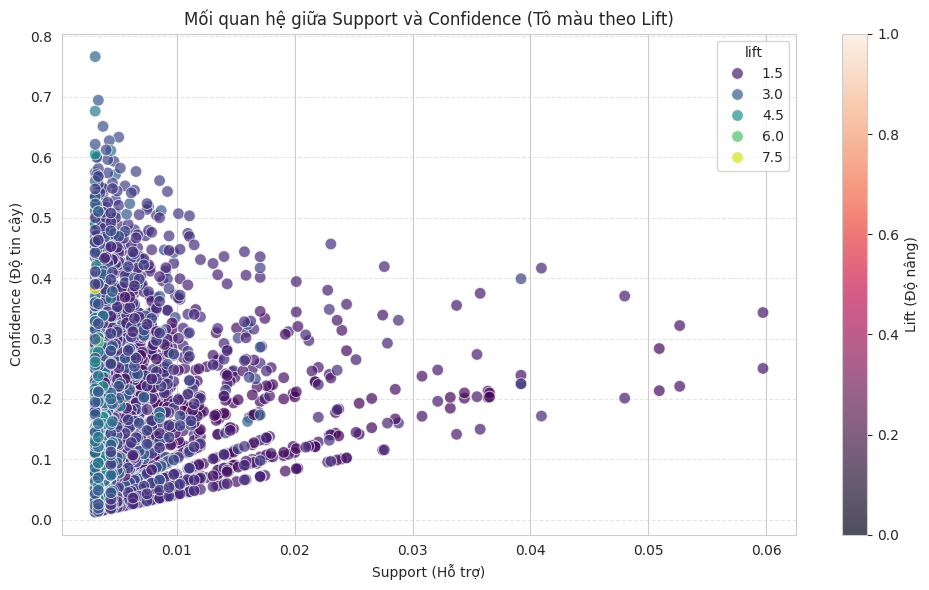

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

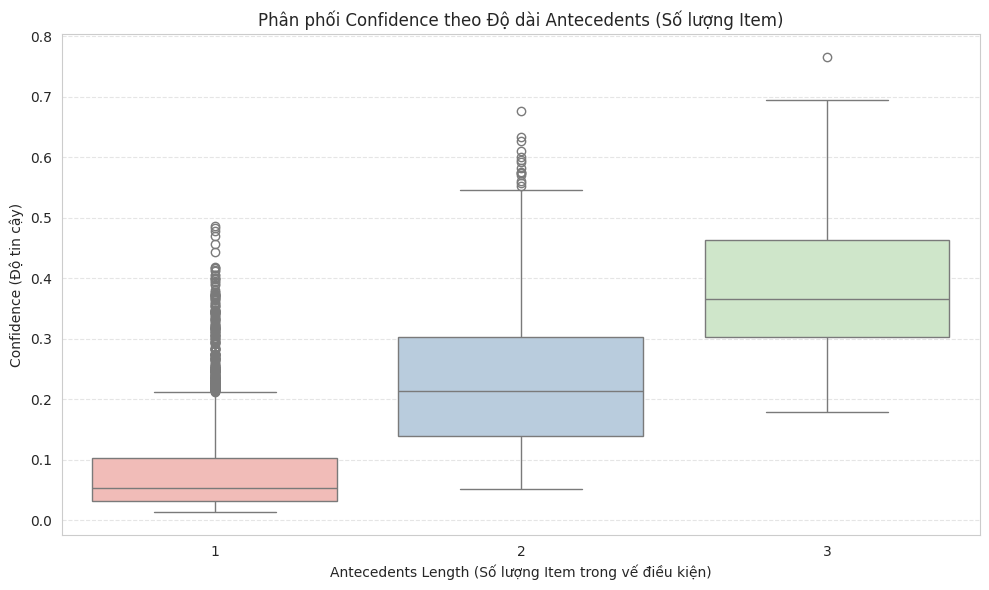

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [9]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Đọc và Tiền xử lý Dữ liệu (Lặp lại từ phân tích trước) ---
try:
    df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'Market_Basket_Optimisation.csv'.")
    exit()

transactions = []
for i in range(len(df)):
    transaction = [str(item) for item in df.iloc[i].dropna()]
    if transaction:
        transactions.append(transaction)

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_ohe = pd.DataFrame(te_ary, columns=te.columns_)

# --- 2. Áp dụng Apriori và Tạo Luật Kết hợp ---
# Sử dụng Min Support thấp để có đủ luật để trực quan hóa
min_support_value = 0.003
frequent_itemsets = apriori(df_ohe, min_support=min_support_value, use_colnames=True)

# Tạo luật kết hợp, sử dụng Min Lift = 1.0 (vì chúng ta muốn thấy tất cả các mối quan hệ)
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

# Thêm cột độ dài cho Antecedents (Số lượng item trong vế điều kiện)
rules['antecedents_length'] = rules['antecedents'].apply(lambda x: len(x))

# --- 3. Trực quan hóa Biểu đồ 1: Support vs Confidence ---

plt.figure(figsize=(10, 6))

# Biểu đồ phân tán giữa Support và Confidence, sử dụng Lift để tô màu các điểm
# Màu sắc: Giá trị Lift càng cao (đỏ) thì luật càng mạnh và có ý nghĩa
scatter = sns.scatterplot(
    x="support",
    y="confidence",
    hue="lift",  # Dùng Lift để tô màu
    data=rules,
    palette="viridis", # Bảng màu đẹp để thể hiện gradient
    alpha=0.7,
    s=70 # Kích thước điểm
)

# Thêm tiêu đề và nhãn
plt.title('Mối quan hệ giữa Support và Confidence (Tô màu theo Lift)')
plt.xlabel('Support (Hỗ trợ)')
plt.ylabel('Confidence (Độ tin cậy)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm chú giải màu sắc (colorbar) cho Lift
cbar = plt.colorbar(scatter.collections[0])
cbar.set_label('Lift (Độ nâng)')

plt.tight_layout()
plt.show()


# --- 4. Trực quan hóa Biểu đồ 2: Antecedent Length vs Confidence ---

plt.figure(figsize=(10, 6))

# Boxplot hoặc Violinplot để xem phân phối Confidence theo số lượng Item
# Sử dụng boxplot để thấy rõ phân phối và giá trị ngoại lai
sns.boxplot(
    x="antecedents_length",
    y="confidence",
    data=rules[rules['antecedents_length'] < 6], # Giới hạn độ dài để biểu đồ dễ đọc
    palette="Pastel1"
)

# Thêm tiêu đề và nhãn
plt.title('Phân phối Confidence theo Độ dài Antecedents (Số lượng Item)')
plt.xlabel('Antecedents Length (Số lượng Item trong vế điều kiện)')
plt.ylabel('Confidence (Độ tin cậy)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Bước 1: Đọc và Tiền xử lý dữ liệu...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Hoàn thành Tiền xử lý. Tổng cộng 7501 giao dịch.

Bước 2: Áp dụng Apriori và tìm Luật Kết hợp...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Đã tìm thấy 4880 luật kết hợp.

Bước 3: Tạo Biểu đồ 1 (Support vs Confidence)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

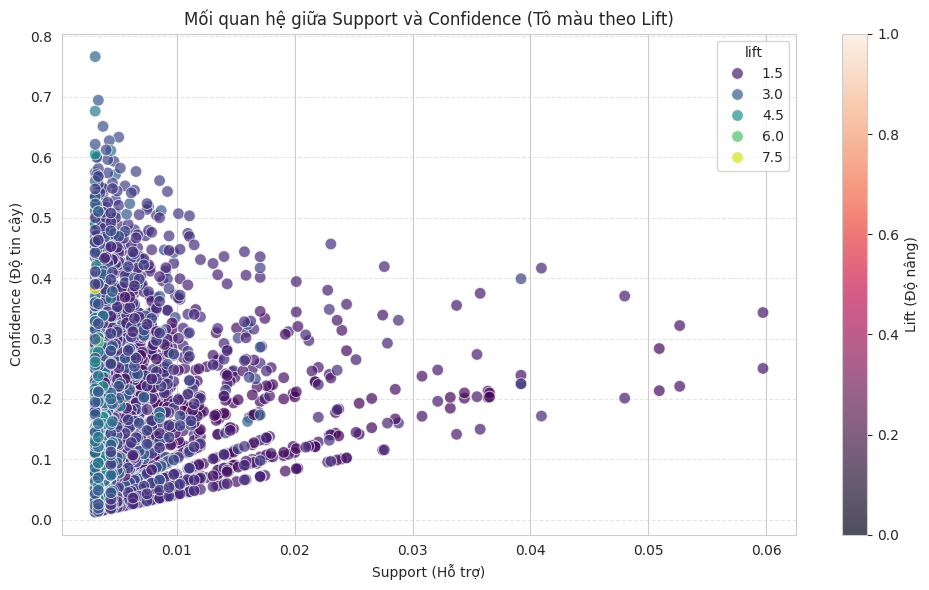

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Bước 4: Tạo Biểu đồ 2 (Antecedent Length vs Confidence)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipython-input-188652832.py:95: F

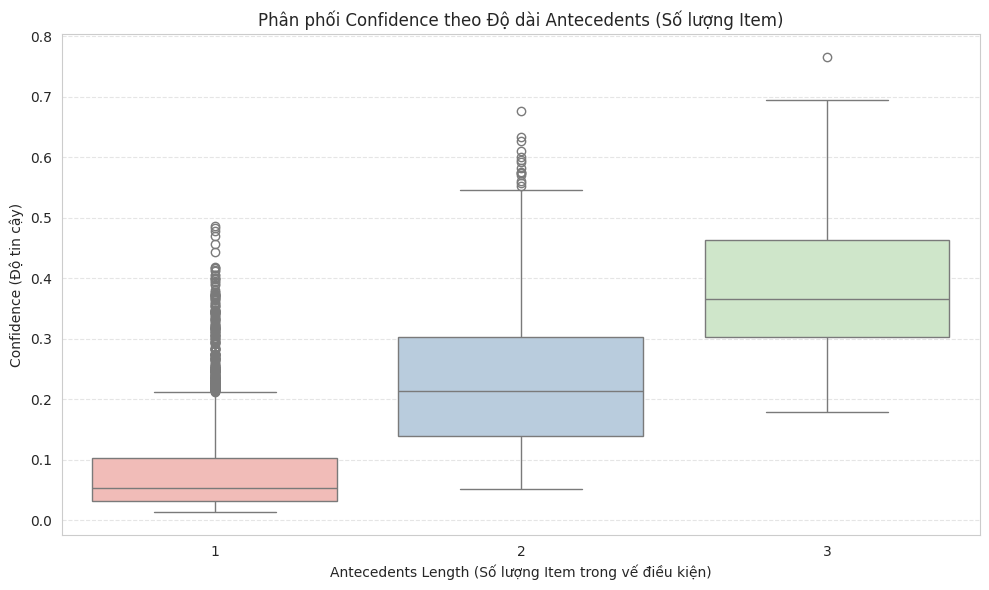


Hoàn thành Trực quan hóa. Hãy kiểm tra các biểu đồ được tạo ra.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [10]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Đọc và Tiền xử lý Dữ liệu ---

print("Bước 1: Đọc và Tiền xử lý dữ liệu...")

# Đọc tệp CSV đã tải lên
try:
    # Đọc tất cả các hàng, giả sử không có tiêu đề
    df = pd.read_csv('Market_Basket_Optimisation.csv', header=None)
except FileNotFoundError:
    print("Lỗi: Không tìm thấy tệp 'Market_Basket_Optimisation.csv'. Vui lòng đảm bảo tệp đã được tải lên.")
    exit()

# Chuyển đổi DataFrame thành một danh sách các giao dịch (List of Lists)
transactions = []
for i in range(len(df)):
    # Lọc bỏ các giá trị NaN (các ô trống)
    transaction = [str(item) for item in df.iloc[i].dropna()]
    if transaction:
        transactions.append(transaction)

# Sử dụng TransactionEncoder để chuyển danh sách giao dịch sang định dạng one-hot encoding
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_ohe = pd.DataFrame(te_ary, columns=te.columns_)

print("Hoàn thành Tiền xử lý. Tổng cộng {} giao dịch.".format(len(transactions)))


# --- 2. Áp dụng Thuật toán Apriori và Tạo Luật Kết hợp ---

print("\nBước 2: Áp dụng Apriori và tìm Luật Kết hợp...")

# Min Support thấp (0.003) để có đủ luật cho việc trực quan hóa
min_support_value = 0.003
frequent_itemsets = apriori(df_ohe, min_support=min_support_value, use_colnames=True)

# Tạo luật kết hợp, sử dụng Min Lift = 1.0 (bao gồm cả các mối quan hệ yếu)
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

# Thêm cột độ dài cho Antecedents (Số lượng item trong vế điều kiện)
rules['antecedents_length'] = rules['antecedents'].apply(lambda x: len(x))

print("Đã tìm thấy {} luật kết hợp.".format(len(rules)))


# --- 3. Trực quan hóa Biểu đồ 1: Support vs Confidence ---

print("\nBước 3: Tạo Biểu đồ 1 (Support vs Confidence)...")

plt.figure(figsize=(10, 6))

# Biểu đồ phân tán giữa Support và Confidence, sử dụng Lift để tô màu các điểm
scatter = sns.scatterplot(
    x="support",
    y="confidence",
    hue="lift",  # Dùng Lift để tô màu
    data=rules,
    palette="viridis", # Bảng màu thể hiện gradient
    alpha=0.7,
    s=70 # Kích thước điểm
)

# Thêm tiêu đề và nhãn
plt.title('Mối quan hệ giữa Support và Confidence (Tô màu theo Lift)')
plt.xlabel('Support (Hỗ trợ)')
plt.ylabel('Confidence (Độ tin cậy)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm chú giải màu sắc (colorbar) cho Lift
cbar = plt.colorbar(scatter.collections[0])
cbar.set_label('Lift (Độ nâng)')

plt.tight_layout()
plt.show()
#


# --- 4. Trực quan hóa Biểu đồ 2: Antecedent Length vs Confidence ---

print("\nBước 4: Tạo Biểu đồ 2 (Antecedent Length vs Confidence)...")

plt.figure(figsize=(10, 6))

# Boxplot để xem phân phối Confidence theo số lượng Item
sns.boxplot(
    x="antecedents_length",
    y="confidence",
    data=rules[rules['antecedents_length'] < 6], # Giới hạn độ dài < 6 để biểu đồ dễ đọc
    palette="Pastel1"
)

# Thêm tiêu đề và nhãn
plt.title('Phân phối Confidence theo Độ dài Antecedents (Số lượng Item)')
plt.xlabel('Antecedents Length (Số lượng Item trong vế điều kiện)')
plt.ylabel('Confidence (Độ tin cậy)')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
#

print("\nHoàn thành Trực quan hóa. Hãy kiểm tra các biểu đồ được tạo ra.")

In [ ]:
#Bài toán 2

In [20]:
import pandas as pd
from collections import defaultdict
from itertools import combinations
from operator import itemgetter


In [21]:
# Đọc dữ liệu Market Basket
data = pd.read_csv("Market_Basket_Optimisation.csv", header=None)

# Tạo danh sách giao dịch
transactions = []
for i in range(data.shape[0]):
    transactions.append(set(data.iloc[i].dropna()))

num_transactions = len(transactions)
print("Số giao dịch:", num_transactions)


Số giao dịch: 7501


In [22]:
min_support = 0.03
min_confidence = 0.5

In [23]:
item_counts = defaultdict(int)

for transaction in transactions:
    for item in transaction:
        item_counts[item] += 1

frequent_itemsets = dict()

frequent_itemsets[1] = {
    frozenset([item]): count
    for item, count in item_counts.items()
    if count / num_transactions >= min_support
}

print("Số item phổ biến:", len(frequent_itemsets[1]))


Số item phổ biến: 36


In [24]:
frequent_itemsets[2] = defaultdict(int)

for transaction in transactions:
    for itemset in combinations(sorted(transaction), 2):
        frequent_itemsets[2][frozenset(itemset)] += 1

frequent_itemsets[2] = {
    itemset: count
    for itemset, count in frequent_itemsets[2].items()
    if count / num_transactions >= min_support
}

print("Số tập 2-item phổ biến:", len(frequent_itemsets[2]))


Số tập 2-item phổ biến: 18


In [26]:
correct_counts = defaultdict(int)
incorrect_counts = defaultdict(int)

for transaction in transactions:
    for premise, conclusion in candidate_rules:
        if premise.issubset(transaction):
            if conclusion in transaction:
                correct_counts[(premise, conclusion)] += 1
            else:
                incorrect_counts[(premise, conclusion)] += 1


In [27]:
rule_confidence = dict()

for rule in candidate_rules:
    correct = correct_counts[rule]
    incorrect = incorrect_counts[rule]
    if correct + incorrect > 0:
        confidence = correct / float(correct + incorrect)
        if confidence >= min_confidence:
            rule_confidence[rule] = confidence

print("Số luật thỏa confidence:", len(rule_confidence))


Số luật thỏa confidence: 0


In [28]:
sorted_confidence = sorted(
    rule_confidence.items(),
    key=itemgetter(1),
    reverse=True
)

top_n = min(5, len(sorted_confidence))

for i in range(top_n):
    (premise, conclusion), confidence = sorted_confidence[i]
    print("Rule #{}".format(i + 1))
    print("If a customer buys {} they will also buy {}"
          .format(set(premise), conclusion))
    print("Confidence: {:.3f}".format(confidence))
    print("")
